# Projeto Integrador – Ciência de Dados Aplicada a Situações de Mercado
## Análise Exploratória de Absenteísmo no Ambiente de Trabalho

Este projeto tem como objetivo analisar fatores relacionados ao absenteísmo corporativo utilizando técnicas de análise exploratória de dados com Python, Pandas e Matplotlib.

## Fonte de Dados

A fonte de dados utilizada neste projeto foi o dataset “Absenteeism at Work”, disponibilizado pela UCI Machine Learning Repository, uma das principais plataformas acadêmicas de datasets para estudos em ciência de dados e aprendizado de máquina.

O conjunto de dados reúne informações relacionadas ao absenteísmo de colaboradores em ambiente corporativo, contendo variáveis como idade, distância entre residência e trabalho, gastos com transporte, índice de massa corporal (IMC), hábitos sociais e motivos de ausência.

Os dados foram obtidos diretamente da plataforma da UCI através da biblioteca Python ucimlrepo, permitindo integração automatizada ao ambiente de análise no Jupyter Notebook.

A escolha deste dataset ocorreu devido à relevância do tema para o contexto empresarial, já que o absenteísmo impacta diretamente a produtividade, os custos operacionais e a gestão de pessoas dentro das organizações.

**[Clique aqui para acessar a referência.](https://archive.ics.uci.edu/dataset/445/absenteeism+at+work)**

#### Importando as bibliotecas:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

#### Importando a tabela:

In [2]:
absenteeism_at_work = fetch_ucirepo(id=445) 

X = absenteeism_at_work.data.features 
y = absenteeism_at_work.data.targets 

#### Visualizando colunas:

In [3]:
X.columns

Index(['Reason for absence', 'Month of absence', 'Day of the week', 'Seasons',
       'Transportation expense', 'Distance from Residence to Work',
       'Service time', 'Age', 'Work load Average/day ', 'Hit target',
       'Disciplinary failure', 'Education', 'Son', 'Social drinker',
       'Social smoker', 'Pet', 'Weight', 'Height', 'Body mass index'],
      dtype='str')

#### Traduzindo colunas:

In [4]:
X = X.rename(columns={
    'Reason for absence': 'motivo_ausencia',
    'Month of absence': 'mes_ausencia',
    'Day of the week': 'dia_semana',
    'Seasons': 'estacao',
    'Transportation expense': 'custo_transporte',
    'Distance from Residence to Work': 'distancia_casa_trabalho',
    'Service time': 'tempo_servico',
    'Age': 'idade',
    'Work load Average/day ': 'carga_trabalho_media_dia',
    'Hit target': 'meta_atingida',
    'Disciplinary failure': 'falha_disciplinar',
    'Education': 'educacao',
    'Son': 'filhos',
    'Social drinker': 'consome_alcool',
    'Social smoker': 'fumante',
    'Pet': 'pets',
    'Weight': 'peso',
    'Height': 'altura',
    'Body mass index': 'imc'}
            )

In [5]:
y = y.rename(columns={
    'Absenteeism time in hours': 'tempo de absenteísmo em horas'}
            )

#### Visualizando dados:

In [6]:
X.sample(5)

,motivo_ausencia,mes_ausencia,dia_semana,estacao,custo_transporte,distancia_casa_trabalho,tempo_servico,idade,carga_trabalho_media_dia,meta_atingida,falha_disciplinar,educacao,filhos,consome_alcool,fumante,pets,peso,altura,imc
583,27,1,5,2,179,51,18,38,313.532,96,0,1,0,1,0,0,89,170,31
189,28,4,6,3,225,26,9,28,326.452,96,0,1,1,0,0,2,69,169,24
660,7,4,2,3,369,17,12,31,246.288,91,0,1,3,1,0,0,70,169,25
591,27,2,5,2,179,26,9,30,264.249,97,0,3,0,0,0,0,56,171,19
161,13,3,5,2,179,26,9,30,343.253,95,0,3,0,0,0,0,56,171,19


In [7]:
y.sample(5)

,tempo de absenteísmo em horas
100,2
307,4
108,2
732,8
648,24


In [8]:
df_completo = pd.concat([X, y], axis = 1)

In [20]:
df_completo.shape

(740, 20)

In [22]:
df_completo.isnull().sum()

motivo_ausencia                  0
mes_ausencia                     0
dia_semana                       0
estacao                          0
custo_transporte                 0
distancia_casa_trabalho          0
tempo_servico                    0
idade                            0
carga_trabalho_media_dia         0
meta_atingida                    0
falha_disciplinar                0
educacao                         0
filhos                           0
consome_alcool                   0
fumante                          0
pets                             0
peso                             0
altura                           0
imc                              0
tempo de absenteísmo em horas    0
dtype: int64

In [23]:
df_completo.duplicated().sum()

np.int64(34)

Como se trata de absenteísmo, esses dados duplicados podem representar que um mesmo indivíduo teve ausência mais de uma vês em datas semelhantes do mesmo mês, podendo representar um absenteísmo padrão semanal por algum motivo justificado ou não

#### Visualizando tipos das colunas:

In [9]:
df_completo.info()

<class 'pandas.DataFrame'>
RangeIndex: 740 entries, 0 to 739
Data columns (total 20 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   motivo_ausencia                740 non-null    int64  
 1   mes_ausencia                   740 non-null    int64  
 2   dia_semana                     740 non-null    int64  
 3   estacao                        740 non-null    int64  
 4   custo_transporte               740 non-null    int64  
 5   distancia_casa_trabalho        740 non-null    int64  
 6   tempo_servico                  740 non-null    int64  
 7   idade                          740 non-null    int64  
 8   carga_trabalho_media_dia       740 non-null    float64
 9   meta_atingida                  740 non-null    int64  
 10  falha_disciplinar              740 non-null    int64  
 11  educacao                       740 non-null    int64  
 12  filhos                         740 non-null    int64  
 13  c

#### Estatísticas Gerais:

In [10]:
df_completo.describe()

,motivo_ausencia,mes_ausencia,dia_semana,estacao,custo_transporte,distancia_casa_trabalho,tempo_servico,idade,carga_trabalho_media_dia,meta_atingida,falha_disciplinar,educacao,filhos,consome_alcool,fumante,pets,peso,altura,imc,tempo de absenteísmo em horas
count,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000
mean,19.216216,6.324324,3.914865,2.544595,221.329730,29.631081,12.554054,36.450000,271.490235,94.587838,0.054054,1.291892,1.018919,0.567568,0.072973,0.745946,79.035135,172.114865,26.677027,6.924324
std,8.433406,3.436287,1.421675,1.111831,66.952223,14.836788,4.384873,6.478772,39.058116,3.779313,0.226277,0.673238,1.098489,0.495749,0.260268,1.318258,12.883211,6.034995,4.285452,13.330998
min,0.000000,0.000000,2.000000,1.000000,118.000000,5.000000,1.000000,27.000000,205.917000,81.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,56.000000,163.000000,19.000000,0.000000
25%,13.000000,3.000000,3.000000,2.000000,179.000000,16.000000,9.000000,31.000000,244.387000,93.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,69.000000,169.000000,24.000000,2.000000
50%,23.000000,6.000000,4.000000,3.000000,225.000000,26.000000,13.000000,37.000000,264.249000,95.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,83.000000,170.000000,25.000000,3.000000
75%,26.000000,9.000000,5.000000,4.000000,260.000000,50.000000,16.000000,40.000000,294.217000,97.000000,0.000000,1.000000,2.000000,1.000000,0.000000,1.000000,89.000000,172.000000,31.000000,8.000000
max,28.000000,12.000000,6.000000,4.000000,388.000000,52.000000,29.000000,58.000000,378.884000,100.000000,1.000000,4.000000,4.000000,1.000000,1.000000,8.000000,108.000000,196.000000,38.000000,120.000000


## Escopo da Exploração dos Dados

O escopo deste projeto consiste na realização de uma análise exploratória dos dados de absenteísmo corporativo, com o objetivo de identificar padrões e fatores que possam influenciar as ausências dos colaboradores no ambiente de trabalho.

A análise será concentrada em variáveis relacionadas às características pessoais, condições de saúde, hábitos de vida e aspectos logísticos dos funcionários. Entre os principais atributos explorados estão:

- Motivo da ausência;  
- Idade dos colaboradores;  
- Distância entre residência e trabalho;  
- Gastos com transporte;  
- Índice de Massa Corporal (IMC);  
- Consumo de álcool;  
- Quantidade de filhos;  
- Horas de absenteísmo.

A exploração dos dados buscará identificar possíveis relações entre essas variáveis e o índice de ausência no trabalho, permitindo gerar insights que possam auxiliar organizações na tomada de decisão estratégica, gestão de pessoas e implementação de ações preventivas relacionadas à saúde e produtividade dos colaboradores.

# Gráficos e Visuzalizações

### Gráfico 1 - Motivos de Ausência
**Objetivo:**  
Identificar os principais motivos responsáveis pelas ausências dos colaboradores.

**Tomada de decisão:**  
Permite que a empresa identifique causas recorrentes de absenteísmo e desenvolva ações preventivas, programas de saúde ocupacional e melhorias no ambiente de trabalho.

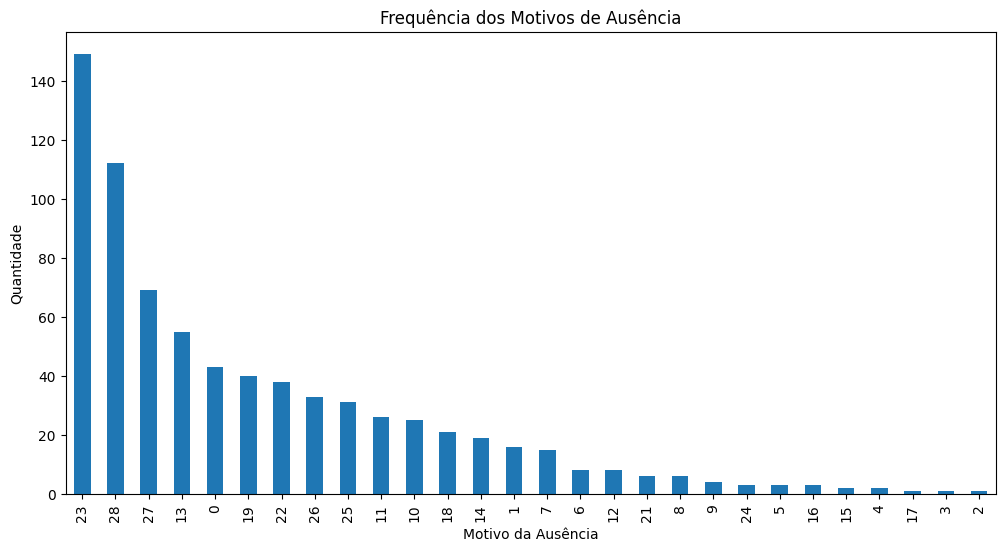

In [11]:
motivos = X['motivo_ausencia'].value_counts()

plt.figure(figsize=(12,6))

motivos.plot(kind='bar')

plt.title('Frequência dos Motivos de Ausência')
plt.xlabel('Motivo da Ausência')
plt.ylabel('Quantidade')

plt.show()

### Gráfico 2 - Distribuição de Idade dos Colaboradores
**Objetivo:**  
Analisar a distribuição etária dos funcionários presentes no dataset.

**Tomada de decisão:**  
Auxilia na identificação de faixas etárias com maior incidência de faltas, permitindo estratégias mais direcionadas de gestão de pessoas e qualidade de vida.

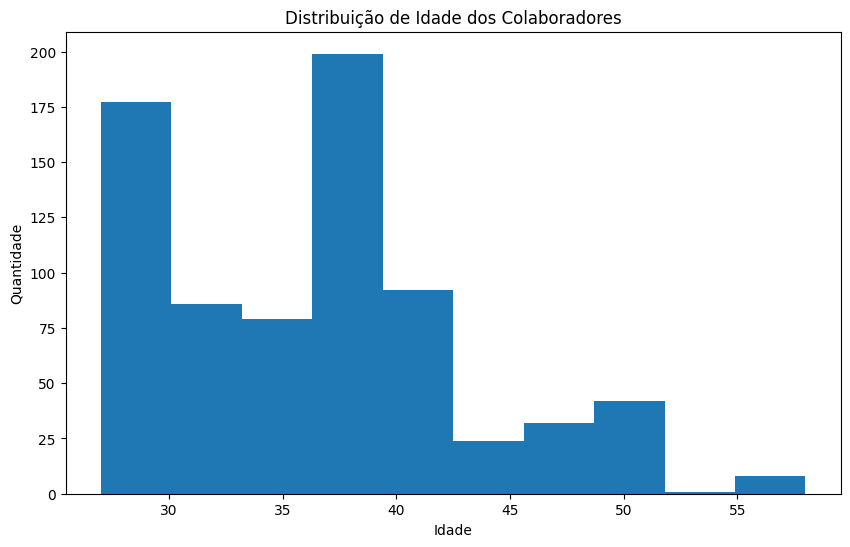

In [12]:
plt.figure(figsize=(10,6))

plt.hist(X['idade'], bins=10)

plt.title('Distribuição de Idade dos Colaboradores')
plt.xlabel('Idade')
plt.ylabel('Quantidade')

plt.show()

### Gráfico 3 - Distância Casa-Trabalho x Horas de Ausência
**Objetivo:**  
Verificar se a distância entre residência e trabalho possui relação com o índice de absenteísmo.

**Tomada de decisão:**  
Pode apoiar decisões relacionadas a flexibilização de jornada, home office e melhorias em políticas de transporte corporativo.

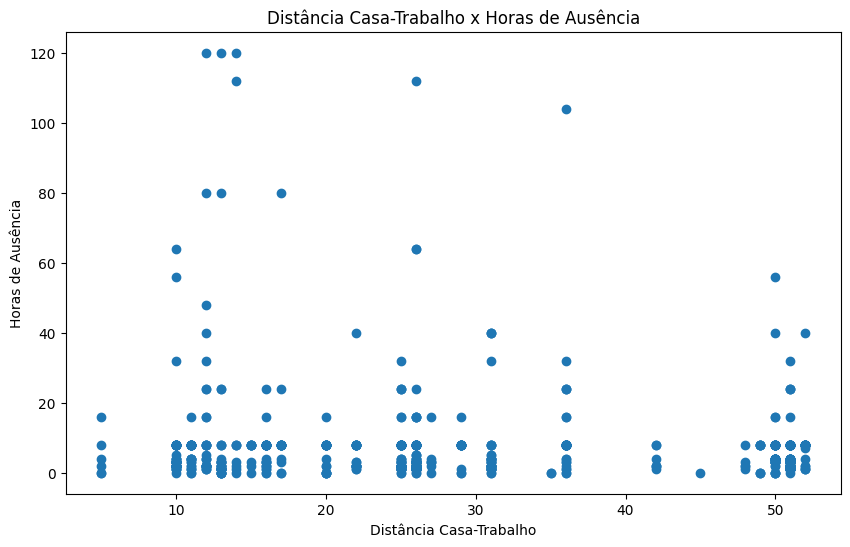

In [13]:
X['horas_ausencia'] = y

plt.figure(figsize=(10,6))

plt.scatter(
    X['distancia_casa_trabalho'],
    X['horas_ausencia']
)

plt.title('Distância Casa-Trabalho x Horas de Ausência')
plt.xlabel('Distância Casa-Trabalho')
plt.ylabel('Horas de Ausência')

plt.show()

### Gráfico 4 - Histograma do absenteísmo
**Objetivo:**  
Mostra a frequência dos valores em intervalos, enquando o KDE apresenta uma curva suavizada da distribuição dos dados. Juntos eles ajudam a identificar concentração, dispersão e o formato da distribuição.

**Tomada de decisão:**  
Ajuda na elaboração de revisão de políticas de ausências curtas (horários flexíveis), parcerias de telemedicina e triagem rápida, identificação de gargalos operacionais(carga de trabalho).

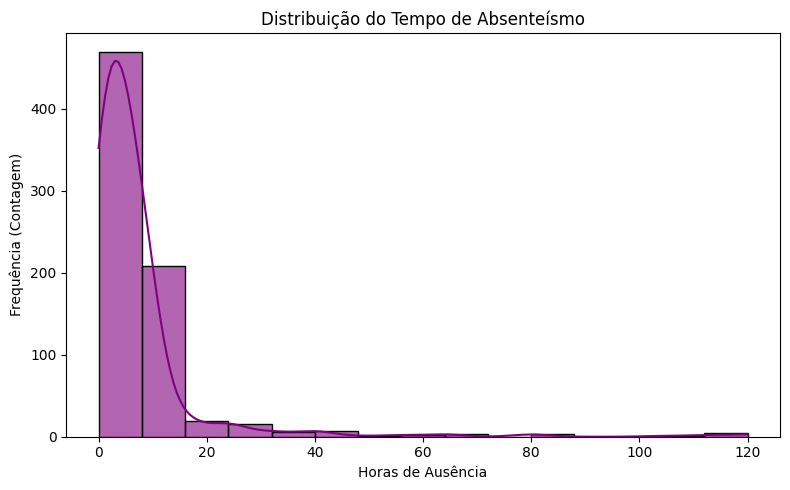

In [38]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_completo, 
    x='tempo de absenteísmo em horas',
    kde=True,
    bins=15,
    color='purple',
    alpha=0.6
)

plt.title('Distribuição do Tempo de Absenteísmo')
plt.xlabel('Horas de Ausência')
plt.ylabel('Frequência (Contagem)')
plt.tight_layout()
plt.show()

### Gráfico 5 - Heatmap
**Objetivo:**  
Analisar possíveis correlações entre todas as features.

**Tomada de decisão:**  
Permite identificar quais variáveis tem maior relação entre si, seja ela positiva ou negativa.

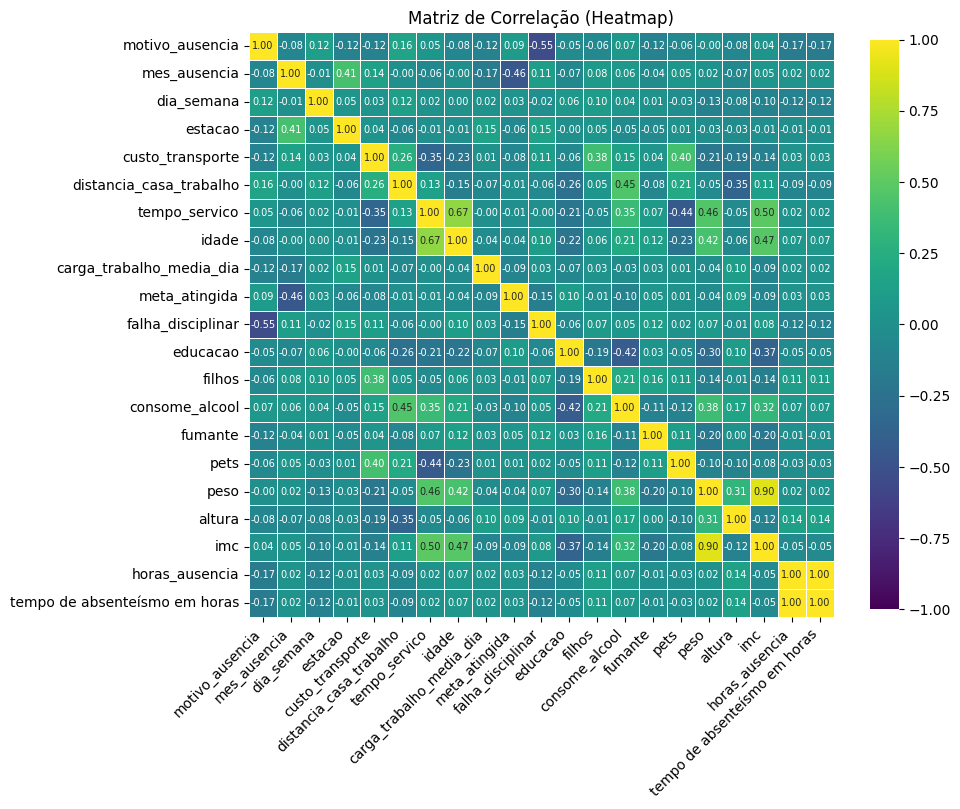

In [24]:
df_completo_corr = pd.concat([X,y], axis=1).corr()

plt.figure(figsize=(10, 12))


sns.heatmap(df_completo_corr,  
            cmap='viridis', 
            vmax=1.0, 
            vmin=-1.0, 
            center=0,
            square=True, 
            linewidths=0.5, 
            cbar_kws={"shrink": 0.5}, 
            annot=True,
            fmt=".2f",
            annot_kws={'size': 7})

plt.title("Matriz de Correlação (Heatmap)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()